In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.stats import kurtosis, skew
import pandas as pd
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
#Sampling Rate is 12,000Hz
files = {
    'Normal':     'Time_Normal_1_098.mat',
    'Inner Race': 'IR007_1_110.mat',
    'Ball':       'B007_1_123.mat',
    'Outer Race': 'OR007_6_1_136.mat'
}

signals = {}

for label, path in files.items():
    mat = scipy.io.loadmat(path)
    
    keys = [k for k in mat.keys() if not k.startswith('__')]
    print(f"\n{label} → Keys: {keys}")
    
    de_key = [k for k in keys if 'DE_time' in k]
    
    if de_key:
        signals[label] = mat[de_key[0]].flatten()
        print(f"{label} → Signal length: {len(signals[label])}")
    else:
        print(f"{label} → DE_time key nahi mili, available: {keys}")


Normal → Keys: ['X098_DE_time', 'X098_FE_time']
Normal → Signal length: 483903

Inner Race → Keys: ['X110_DE_time', 'X110_FE_time', 'X110RPM']
Inner Race → Signal length: 486224

Ball → Keys: ['X123_DE_time', 'X123_FE_time', 'X123RPM']
Ball → Signal length: 487384

Outer Race → Keys: ['X136_DE_time', 'X136_FE_time', 'X136RPM']
Outer Race → Signal length: 486804


In [3]:
# DC offset removal — vibration signals must be zero-mean
# Raw accelerometer data can have a constant voltage bias
# which is not part of the vibration — we remove it

for label in signals:
    before = np.mean(signals[label])
    signals[label] = signals[label] - np.mean(signals[label])
    after = np.mean(signals[label])
    print(f"{label} → mean before: {before:.6f} | mean after: {after:.6f}")

print("\nDC offset removal complete.")

Normal → mean before: 0.012564 | mean after: 0.000000
Inner Race → mean before: 0.020731 | mean after: -0.000000
Ball → mean before: 0.019031 | mean after: 0.000000
Outer Race → mean before: 0.012112 | mean after: -0.000000

DC offset removal complete.


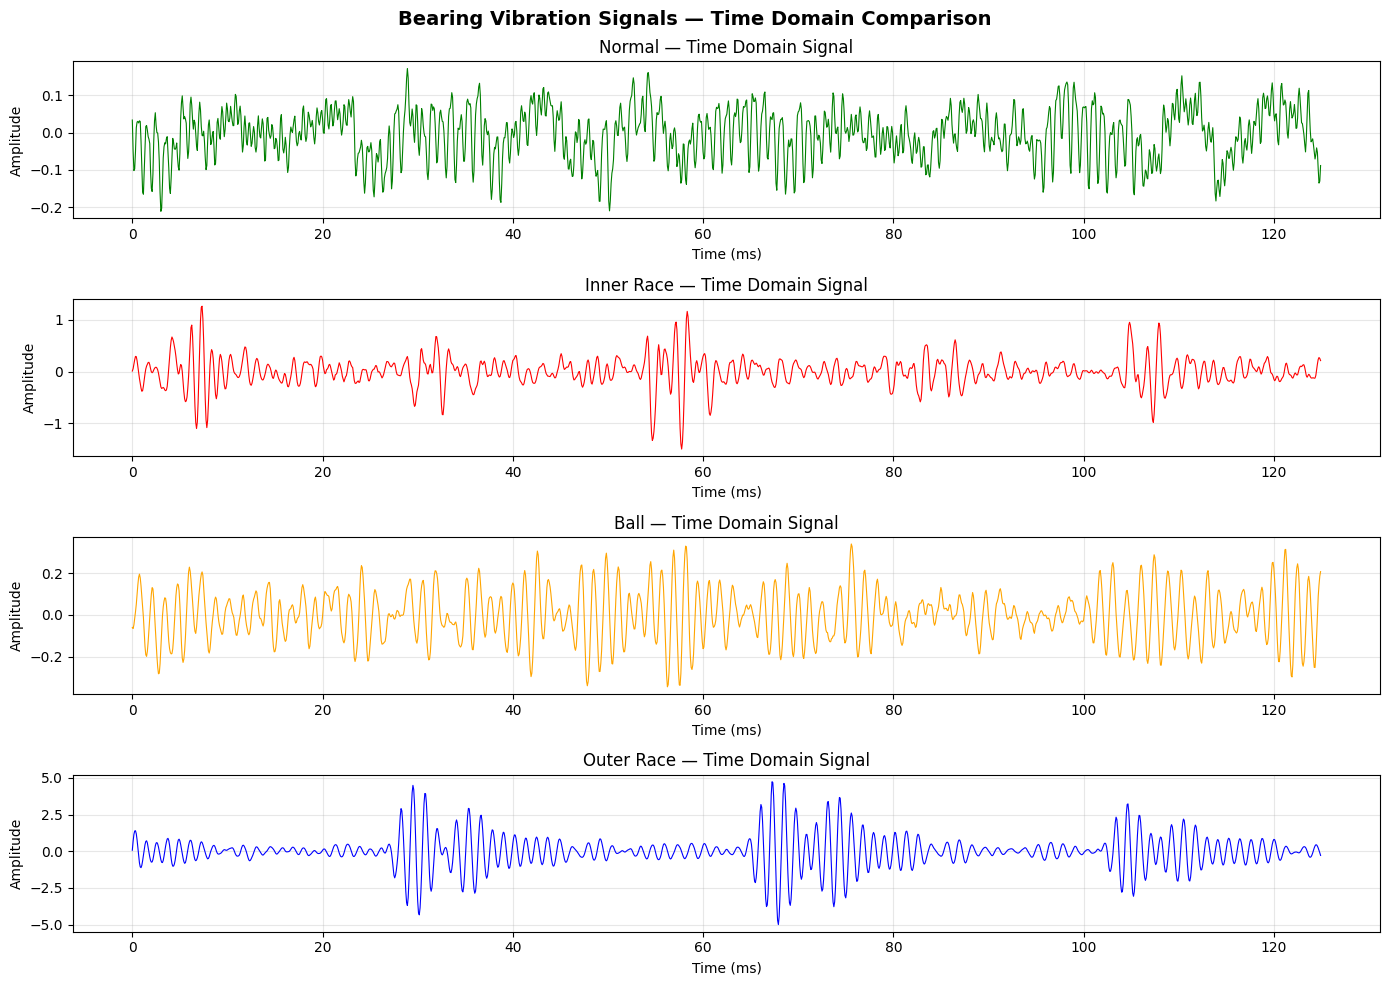

In [4]:
fs = 12000
samples = 1500

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

colors = ['green', 'red', 'orange', 'blue']

for ax, (label, signal), color in zip(axes, signals.items(), colors):
    t = np.arange(samples) / fs * 1000
    ax.plot(t, signal[:samples], color=color, linewidth=0.8)
    ax.set_title(f"{label} — Time Domain Signal", fontsize=12)
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

plt.suptitle("Bearing Vibration Signals — Time Domain Comparison", 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

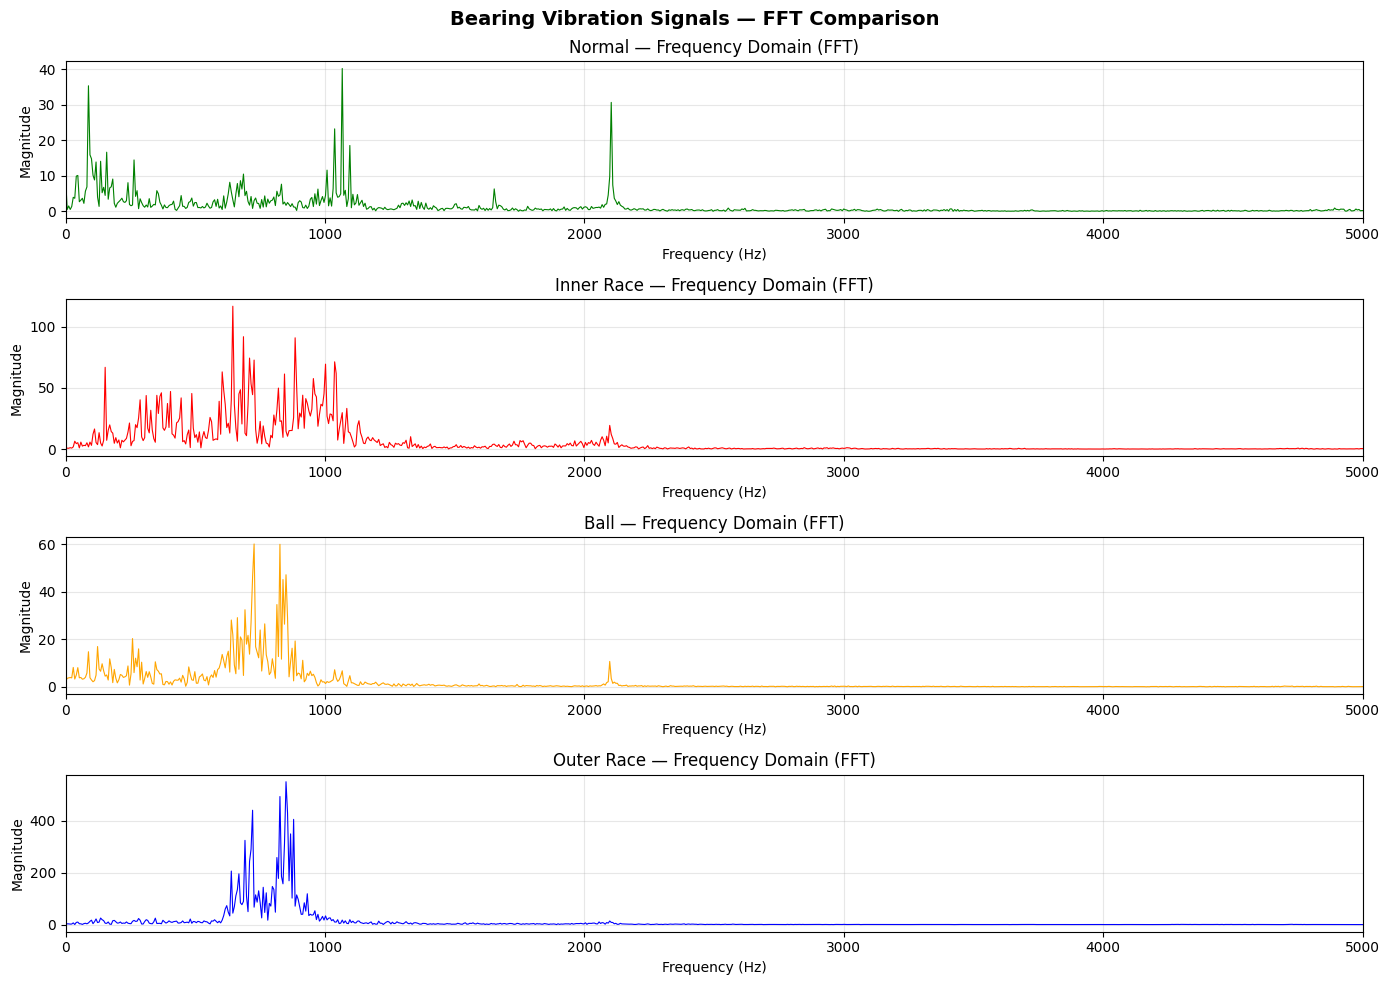

In [5]:
N = 2048

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

colors = ['green', 'red', 'orange', 'blue']

for ax, (label, signal), color in zip(axes, signals.items(), colors):
    spectrum = np.abs(fft(signal[:N]))[:N//2]
    freqs    = fftfreq(N, d=1/fs)[:N//2]
    
    ax.plot(freqs, spectrum, color=color, linewidth=0.8)
    ax.set_title(f"{label} — Frequency Domain (FFT)", fontsize=12)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude")
    ax.set_xlim([0, 5000])
    ax.grid(True, alpha=0.3)

plt.suptitle("Bearing Vibration Signals — FFT Comparison",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
#Feature Extraction
def extract_features(signal, fs=12000, N=2048):
    seg = signal[:N]
    rms = np.sqrt(np.mean(seg**2))
    peak = np.max(np.abs(seg))
    
    return {
        'mean':         np.mean(seg),
        'std':          np.std(seg),
        'rms':          rms,
        'peak':         peak,
        'kurtosis':     kurtosis(seg),
        'skewness':     skew(seg),
        'crest_factor': peak / (rms + 1e-10),
        'peak_to_peak': np.max(seg) - np.min(seg),
        'fft_mean':     np.mean(np.abs(fft(seg))[:N//2]),
        'fft_std':      np.std(np.abs(fft(seg))[:N//2]),
        'fft_peak':     np.max(np.abs(fft(seg))[:N//2]),
    }

# Har fault type ka feature print karo
print(f"{'Feature':<20} {'Normal':>10} {'Inner Race':>12} {'Ball':>10} {'Outer Race':>12}")
print("-" * 68)

feature_names = list(extract_features(list(signals.values())[0]).keys())

for feat in feature_names:
    values = [extract_features(sig)[feat] for sig in signals.values()]
    print(f"{feat:<20} {values[0]:>10.4f} {values[1]:>12.4f} {values[2]:>10.4f} {values[3]:>12.4f}")

Feature                  Normal   Inner Race       Ball   Outer Race
--------------------------------------------------------------------
mean                    -0.0046       0.0003    -0.0012      -0.0028
std                      0.0664       0.2804     0.1227       1.0125
rms                      0.0666       0.2804     0.1227       1.0125
peak                     0.2114       1.5274     0.4379       4.9972
kurtosis                -0.1802       4.7710    -0.0393       4.3868
skewness                -0.2780      -0.0989    -0.1187       0.0734
crest_factor             3.1737       5.4466     3.5685       4.9357
peak_to_peak             0.4030       3.0243     0.7788       9.7406
fft_mean                 1.1131       4.8026     1.7377      10.5469
fft_std                  2.8086      11.7472     5.2752      44.5885
fft_peak                40.1879     116.8261    60.1507     549.5618


In [7]:
def build_dataset(signals_dict, fs=12000, N=2048, stride=1024):
    """
    Har signal pe sliding window chalao
    N = window size (2048 samples)
    stride = kitna khisako har baar (1024 = 50% overlap)
    """
    rows = []
    
    for label, signal in signals_dict.items():
        start = 0
        window_count = 0
        
        while start + N <= len(signal):
            window = signal[start : start + N]
            feats = extract_features(window, fs, N)
            feats['label'] = label
            rows.append(feats)
            start += stride
            window_count += 1
        
        print(f"{label} → {window_count} windows created")
    
    df = pd.DataFrame(rows)
    print(f"\nTotal dataset shape: {df.shape}")
    print(f"\nClass distribution:")
    print(df['label'].value_counts())
    return df

# Dataset banao
df = build_dataset(signals)

Normal → 471 windows created
Inner Race → 473 windows created
Ball → 474 windows created
Outer Race → 474 windows created

Total dataset shape: (1892, 12)

Class distribution:
label
Outer Race    474
Ball          474
Inner Race    473
Normal        471
Name: count, dtype: int64


In [8]:
# CSV mein save karo
df.to_csv('features_dataset.csv', index=False)
print("Dataset saved!")

# Pehli 5 rows dekho
df.head()

Dataset saved!


,mean,std,rms,peak,kurtosis,skewness,crest_factor,peak_to_peak,fft_mean,fft_std,fft_peak,label
0,-0.004562,0.066445,0.066601,0.211375,-0.180225,-0.277955,3.173739,0.403045,1.113078,2.808561,40.187853,Normal
1,-0.002288,0.065041,0.065081,0.209914,-0.086259,-0.225813,3.225418,0.401793,1.102862,2.732923,37.591026,Normal
2,-0.002968,0.062987,0.063057,0.209914,-0.016090,-0.272366,3.328940,0.401793,1.086951,2.641952,34.224900,Normal
3,-0.002619,0.063640,0.063694,0.194894,-0.191945,-0.200513,3.059860,0.387190,1.080435,2.674926,34.028017,Normal
4,-0.001748,0.063052,0.063076,0.198763,-0.193607,-0.210519,3.151184,0.391571,1.070150,2.647472,35.612890,Normal


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features aur labels alag karo
X = df.drop('label', axis=1)  # sirf numbers
y = df['label']                # sirf labels

# Label encoding — string ko number mein badlo
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("Encoded as:", list(range(len(le.classes_))))

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded  # har class equally split ho
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Classes: ['Ball' 'Inner Race' 'Normal' 'Outer Race']
Encoded as: [0, 1, 2, 3]

Training samples: 1513
Testing samples:  379


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Model banao
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train karo
print("Training model...")
rf_model.fit(X_train, y_train)
print("Training complete!")

# Predict karo
y_pred = rf_model.predict(X_test)

# Accuracy dekho
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

Training model...
Training complete!

Model Accuracy: 100.00%


In [11]:
print("\nDetailed Classification Report:")
print("="*55)
print(classification_report(
    y_test, 
    y_pred, 
    target_names=le.classes_
))


Detailed Classification Report:
              precision    recall  f1-score   support

        Ball       1.00      1.00      1.00        95
  Inner Race       1.00      1.00      1.00        95
      Normal       1.00      1.00      1.00        94
  Outer Race       1.00      1.00      1.00        95

    accuracy                           1.00       379
   macro avg       1.00      1.00      1.00       379
weighted avg       1.00      1.00      1.00       379



In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

models = {
    'Random Forest':     RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':     DecisionTreeClassifier(random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=5),
    'SVM':               SVC(kernel='rbf', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':       GaussianNB(),
}

print(f"{'Model':<25} {'Accuracy':>10}")
print("="*38)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name:<25} {acc*100:>9.2f}%")

Model                       Accuracy
Random Forest                100.00%
Decision Tree                 99.74%
KNN                           99.74%
SVM                           98.42%
Logistic Regression           99.74%
Naive Bayes                  100.00%


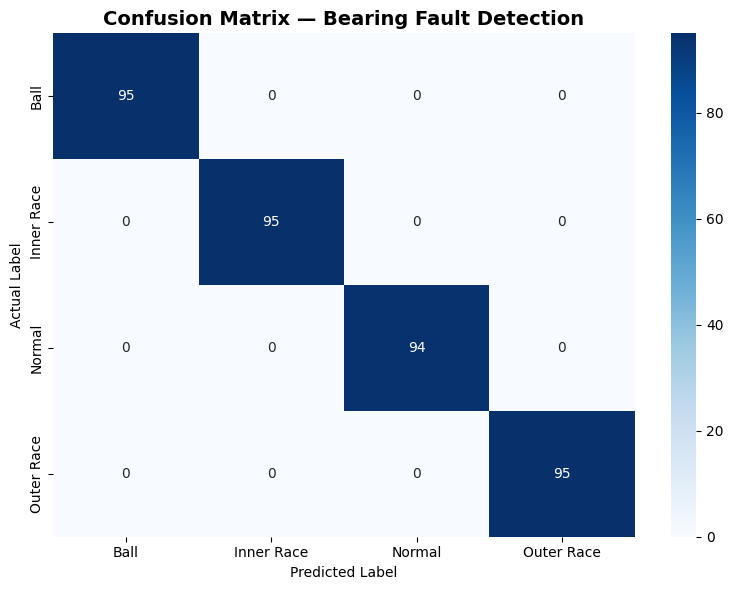

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title('Confusion Matrix — Bearing Fault Detection', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

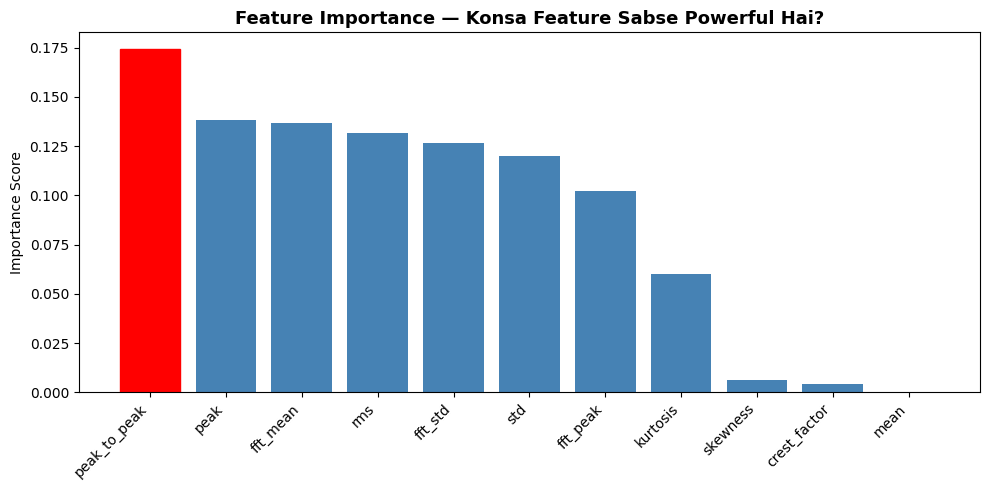


Top 3 Most Important Features:
1. peak_to_peak → 0.1741
2. peak → 0.1381
3. fft_mean → 0.1369


In [14]:
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(feature_names)), 
        importances[indices], 
        color='steelblue')

# Top feature highlight karo
bars[0].set_color('red')

plt.xticks(range(len(feature_names)), 
           [feature_names[i] for i in indices], 
           rotation=45, ha='right')
plt.title('Feature Importance — Konsa Feature Sabse Powerful Hai?', 
          fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

# Top 3 print karo
print("\nTop 3 Most Important Features:")
for i in range(3):
    print(f"{i+1}. {feature_names[indices[i]]} → {importances[indices[i]]:.4f}")

In [15]:
import joblib

# Model save karo
joblib.dump(rf_model, 'bearing_fault_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model saved successfully!")
print("Files created:")
print("  → bearing_fault_model.pkl")
print("  → label_encoder.pkl")

Model saved successfully!
Files created:
  → bearing_fault_model.pkl
  → label_encoder.pkl


In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib

# Step 1 — separate features and labels
X = df.drop('label', axis=1)
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Step 2 — compare models FAIRLY, all with StandardScaler inside Pipeline
models = {
    'Random Forest':       Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))]),
    'Decision Tree':       Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeClassifier(random_state=42))]),
    'KNN':                 Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'SVM':                 Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', random_state=42))]),
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Naive Bayes':         Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())]),
}

print(f"\n{'Model':<25} {'Accuracy':>10}")
print("=" * 38)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"{name:<25} {acc*100:>9.2f}%")

# Step 3 — train final pipeline (RF) and cross-validate
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print(f"\nFinal model accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Step 4 — cross validation
cv_scores = cross_val_score(final_pipeline, X, y_encoded, cv=5, scoring='accuracy')
print(f"\n5-Fold CV scores: {cv_scores}")
print(f"Mean: {cv_scores.mean()*100:.2f}% | Std: {cv_scores.std()*100:.2f}%")

# Step 5 — save correctly as ONE pipeline file
joblib.dump(final_pipeline, 'pipeline.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("\nSaved: pipeline.pkl and label_encoder.pkl")

Classes: ['Ball' 'Inner Race' 'Normal' 'Outer Race']

Model                       Accuracy
Random Forest                100.00%
Decision Tree                 99.74%
KNN                           99.21%
SVM                          100.00%
Logistic Regression           99.74%
Naive Bayes                  100.00%

Final model accuracy: 100.00%

5-Fold CV scores: [1. 1. 1. 1. 1.]
Mean: 100.00% | Std: 0.00%

Saved: pipeline.pkl and label_encoder.pkl


In [17]:
#Noise robustness test
noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5]

print(f"{'Noise Level':<15} {'Accuracy':>10}")
print("=" * 28)

for noise in noise_levels:
    X_noisy = X_test.copy()
    X_noisy = X_noisy + np.random.normal(0, noise, X_noisy.shape)
    acc = accuracy_score(y_test, final_pipeline.predict(X_noisy))
    print(f"{noise:<15} {acc*100:>9.2f}%")

Noise Level       Accuracy
0.01               100.00%
0.05                99.74%
0.1                100.00%
0.2                 99.74%
0.5                 98.15%


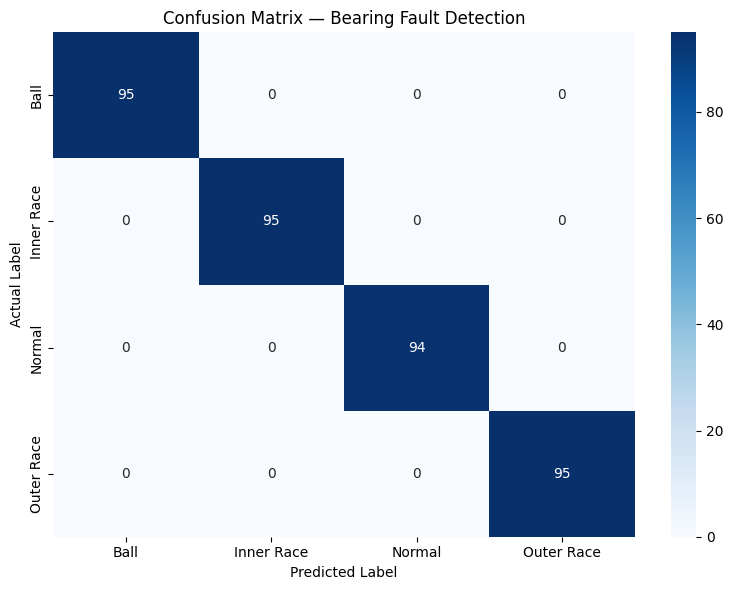

Saved: results/confusion_matrix.png


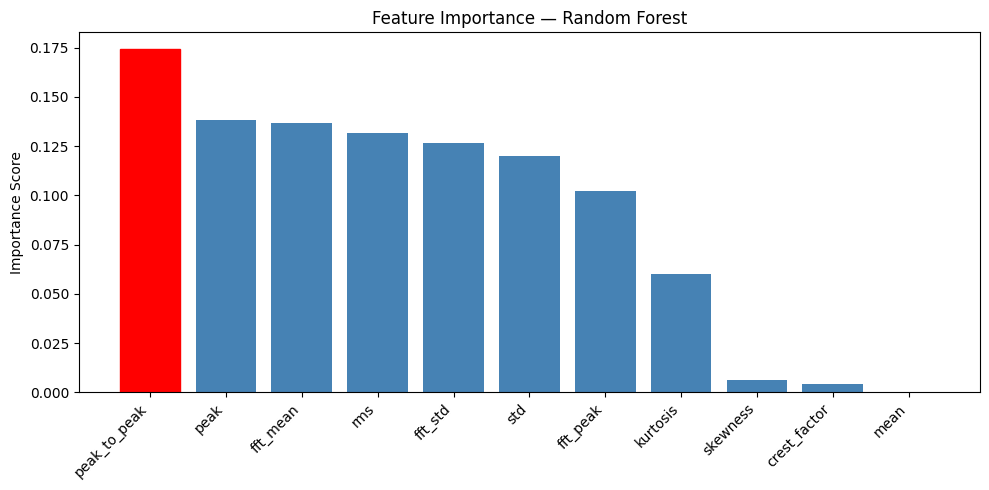

Saved: results/feature_importance.png

Phase 3 complete.


In [18]:
import os
os.makedirs('results', exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_)
plt.title('Confusion Matrix — Bearing Fault Detection')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150)
plt.show()
print("Saved: results/confusion_matrix.png")

feature_names = X.columns.tolist()
importances = final_pipeline.named_steps['model'].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
bars = plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
bars[0].set_color('red')
plt.xticks(range(len(feature_names)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title('Feature Importance — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150)
plt.show()
print("Saved: results/feature_importance.png")
print("\nPhase 3 complete.")